In [1]:
from pathlib import Path
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import tables_io
import matplotlib.pyplot as plt 
%matplotlib inline 


In [2]:

widegalaxy=tables_io.read('/project/kicp/chto/roman-sompz/hlwas_cosmos_260120_UM_2026_01_22.parquet')
widegalaxy_assignment=tables_io.read('/project/kicp/chto/roman-sompz/widedata_wide_assignment.hdf5')
tomotbinwide = tables_io.read("/project/kicp/chto/roman-sompz/tomo_bins_wide.hdf5")
widebinning = tomotbinwide['tomo_bins_wide'][:,0][widegalaxy_assignment['cells']]

column_list None


In [3]:
wzsample = tables_io.read("/project/kicp/chto/roman-sompz/photoz_realizations.hdf5")

In [4]:
wzsamples = []
for keys in wzsample.keys():
    wzsamples.append(wzsample[keys])
wzsamples = np.concatenate(wzsamples, axis=0)    

In [9]:
import h5py
tomotbinwide_ref  = h5py.File("/project/kicp/chto/roman-sompz/FINAL_NZ.hdf5",'r')

array([[0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
        1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
        1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
        2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
        2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25,
        3.3 , 3.35, 3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 ,
        3.85, 3.9 , 3.95, 4.  , 4.05, 4.1 , 4.15, 4.2 , 4.25, 4.3 , 4.35,
        4.4 , 4.45, 4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 ,
        4.95, 5.  ]])

In [16]:
redshiftcol='specz'
zbins = tomotbinwide_ref['meta/xvals'][:][0]
zbinsc = 0.5*(zbins[1:]+zbins[:-1])


ValueError: x and y must have same first dimension, but have shapes (100,) and (101,)

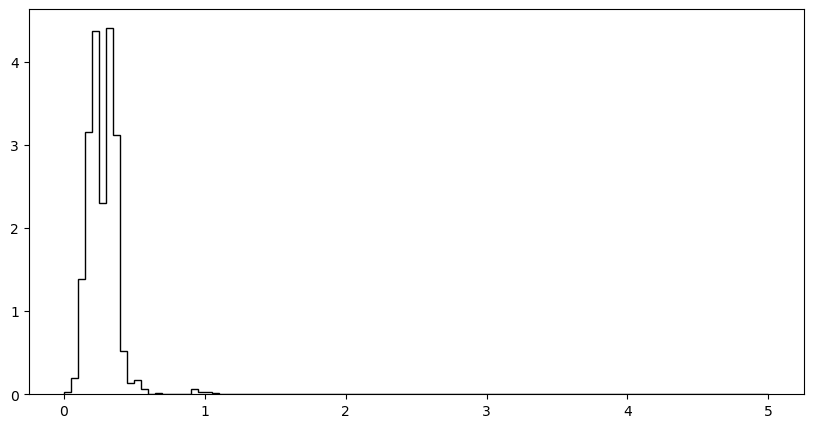

In [17]:
import seaborn as sns
colors = sns.color_palette('colorblind')
fig = plt.figure(figsize=(10,5))
for i in range(5):
    if i==0:
        name="True"
    else:
        name=None
    plt.hist(np.array(widegalaxy[redshiftcol])[widebinning==i], density=True, histtype="step", bins=zbins, color='k', label=name)
    plt.plot(zbinsc,tomotbinwide_ref['data/yvals'][:][i], "-", label="bin: "+str(i), c=colors[i])
    violin_parts = plt.violinplot(wzsamples[:,i,:]/(zbinsc[1]-zbinsc[0]), positions=zbinsc, widths=0.04, showmeans=False, showmedians=False, showextrema=False, quantiles = None)
    for pc in violin_parts['bodies']:
        pc.set_facecolor(colors[i])
        pc.set_edgecolor(colors[i])
plt.legend()
plt.xlabel("z")
plt.ylabel("p(z)")
plt.xlim(0,3.2)
